<a href="https://colab.research.google.com/github/Aayush974/learning-pytorch/blob/main/01_classificationNetwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Non-linear Binary classification

the chosen dataset for this section is the make_moons dataset from scikit datasets, the make_moons return two arrays.
The first being the coordinates and the second being the class of those coordinates. The goal of this section will be to develop a nn such that given a point it can correctly guess the class of that point


shape of x:  torch.Size([1000, 2])
shape of y:  torch.Size([1000])


,X1,X2,label
0,0.754246,0.231481,1.0
1,-0.756159,0.153259,1.0
2,-0.815392,0.173282,1.0
3,-0.393731,0.692883,1.0
4,0.442208,-0.896723,0.0
5,-0.479646,0.676435,1.0
6,-0.013648,0.803349,1.0
7,0.771513,0.147760,1.0
8,-0.169322,-0.793456,1.0
9,-0.121486,1.021509,0.0


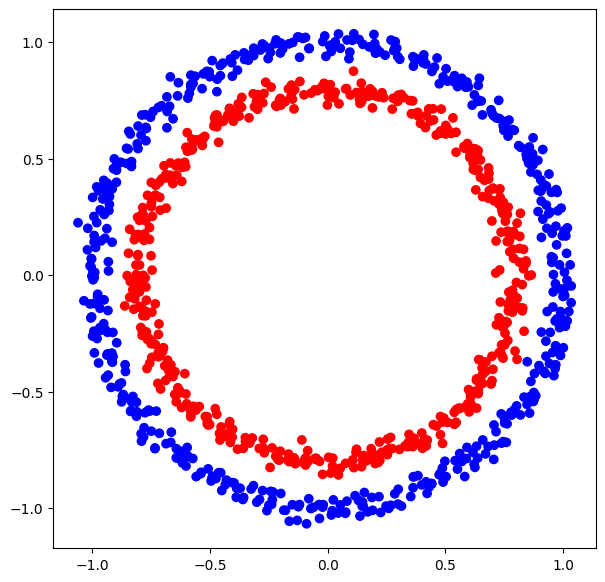

In [ ]:
from sklearn.datasets import make_circles
import torch
from matplotlib import pyplot as plt
import pandas as pd
torch.manual_seed(42)
x,y = make_circles(n_samples=1000,noise=0.03,random_state=42)

# coverting numpy arrays to tensors
x = torch.from_numpy(x).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

print("shape of x: ",x.shape)
print("shape of y: ",y.shape)

plt.figure(figsize=(7,7))
plt.scatter(x[:,0],x[:,1],c=y, cmap = "bwr")

circles = pd.DataFrame({
    "X1":x[:,0],
    "X2":x[:,1],
    "label":y
})
circles.head(10)


## Splitting Data into training and testing

In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

torch.Size([800, 2]) torch.Size([200, 2]) torch.Size([800]) torch.Size([200])


## setting up device agnostic code

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# moving the tensors

x_train = x_train.to(device)
x_test = x_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)


## Building a model


### Trying with a linear model

this is to show that a non linear problem can't be solved using linear transformations

In [ ]:
from torch import nn
class circle_model0(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Linear(in_features=2,out_features=5)
    self.layer2 = nn.Linear(in_features=5 ,out_features=1)

  def forward(self,x):
    return self.layer2(self.layer1(x))

model0 = circle_model0().to(device)
model0.state_dict()

OrderedDict([('layer1.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188]], device='cuda:0')),
             ('layer1.bias',
              tensor([0.6146, 0.1323, 0.5224, 0.0958, 0.3410], device='cuda:0')),
             ('layer2.weight',
              tensor([[-0.0631,  0.3448,  0.0661, -0.2088,  0.1140]], device='cuda:0')),
             ('layer2.bias', tensor([-0.2060], device='cuda:0'))])

the above is a simple linear model one slight change as compared to previous notebook is the use of nn.Linear to build a layer which applies linear transformation to the incoming data based on the formula

y = xW<sup>t</sup> + b

where
- x is the incoming data
- W<sup>t</sup> is the transpose of the weight tensor
- b is the bias
- y is the output of the linear transformation

the weights and bias are set implicitly behind the scenes. The bias can be opted out of by passing bias=False to the function

In [ ]:
torch.manual_seed(42)
# setting the loss function and optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model0.parameters(),lr=0.01)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    acc = (correct / len(y_pred)) * 100
    return acc

for epoch in range(2000):
  model0.train()

  y_logits = model0(x_train).squeeze() # logits are used to refer to the raw ouput of the network
  y_preds = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits,y_train)
  acc = accuracy_fn(y_true=y_train,y_pred=y_preds)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model0.eval()
  with torch.inference_mode():
        # 1. Forward pass
        test_logits = model0(x_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        # 2. Caculate loss/accuracy
        test_loss = loss_fn(test_logits,
                            y_test)
        test_acc = accuracy_fn(y_true=y_test,
                               y_pred=test_pred)

    # Print out what's happening every 100 epochs
        if epoch % 100 == 0:
          print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")


Epoch: 0 | Loss: 0.69569, Accuracy: 50.00% | Test loss: 0.69739, Test acc: 50.00%
Epoch: 100 | Loss: 0.69405, Accuracy: 50.00% | Test loss: 0.69622, Test acc: 50.00%
Epoch: 200 | Loss: 0.69344, Accuracy: 45.88% | Test loss: 0.69587, Test acc: 47.00%
Epoch: 300 | Loss: 0.69322, Accuracy: 49.12% | Test loss: 0.69577, Test acc: 47.00%
Epoch: 400 | Loss: 0.69312, Accuracy: 49.00% | Test loss: 0.69573, Test acc: 47.00%
Epoch: 500 | Loss: 0.69308, Accuracy: 50.12% | Test loss: 0.69569, Test acc: 46.50%
Epoch: 600 | Loss: 0.69306, Accuracy: 50.25% | Test loss: 0.69564, Test acc: 46.00%
Epoch: 700 | Loss: 0.69305, Accuracy: 50.25% | Test loss: 0.69559, Test acc: 46.00%
Epoch: 800 | Loss: 0.69304, Accuracy: 50.75% | Test loss: 0.69554, Test acc: 46.50%
Epoch: 900 | Loss: 0.69303, Accuracy: 50.50% | Test loss: 0.69548, Test acc: 46.50%
Epoch: 1000 | Loss: 0.69302, Accuracy: 50.50% | Test loss: 0.69543, Test acc: 46.50%
Epoch: 1100 | Loss: 0.69302, Accuracy: 50.62% | Test loss: 0.69537, Test acc:

as evident from the output, the loss and accuracy remain fixed  in the range of 45~55 for even 2000 epochs, which is as good as random guessing

this shows that a non linear dataset cannot be solved by using linear transformations

### Decision boundary function

let's define a decision boundary plotting function which will help us see the decision boundary of the model

In [ ]:
import numpy as np
def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor):
    """Plots decision boundaries of model predicting on X in comparison to y.

    Source - https://madewithml.com/courses/foundations/neural-networks/ (with modifications)
    """
    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Setup prediction boundaries and grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)  # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits))  # binary

        # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

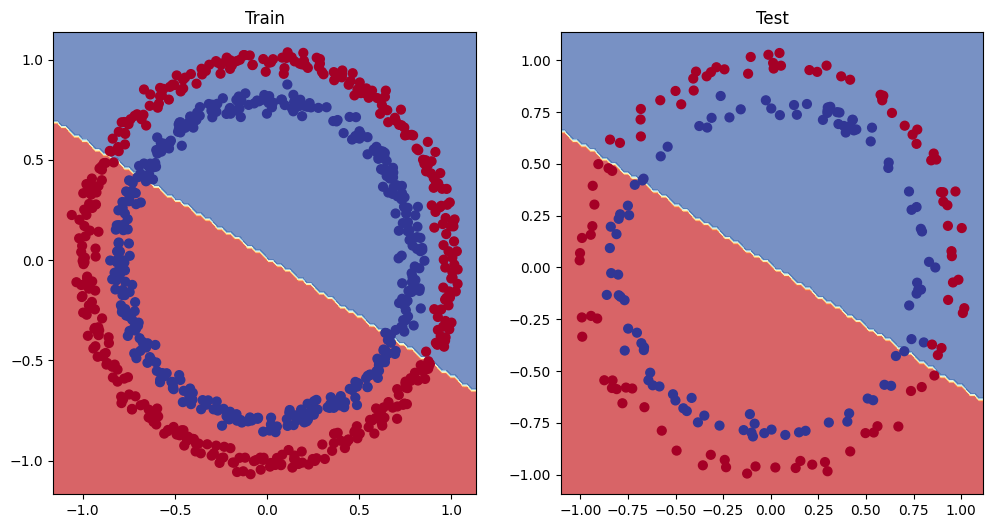

In [ ]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model0, x_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model0, x_test, y_test)

The decision boundary shows us exactly why our previous model failed. Linear transformations cause a straight line to be drawn thru the datasets and since the datset is linearly seperable hence the model is stuck

### Non-linear model

to introduce non-linearity in our model we will use the ReLu function which is defined as

f(x) = max(0,x)

 relu returns the highest value between 0 and x, i.e it ignores negative values.

In [ ]:
from torch import nn
class circle_model1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Linear(in_features=2,out_features=5)
    self.layer2 = nn.Linear(in_features=5 ,out_features=1)
    self.relu = nn.ReLU()
  def forward(self,x):
    return self.layer2(self.relu(self.layer1(x)))

model1 = circle_model1().to(device)

In [ ]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model1.parameters(),lr=0.1)

for epoch in range(2000):
  model1.train()

  y_logits = model1(x_train).squeeze()
  y_preds = torch.round(torch.sigmoid(y_logits))

  acc = accuracy_fn(y_true=y_train,y_pred=y_preds)

  optimizer.zero_grad()

  loss = loss_fn(y_logits,y_train)

  loss.backward()

  optimizer.step()

  model0.eval()
  with torch.inference_mode():
    test_logits = model1(x_test).squeeze()
    test_preds = torch.round(torch.sigmoid(test_logits))
    test_acc = accuracy_fn(y_true=y_test,y_pred=test_preds)
    test_loss = loss_fn(test_logits,y_test)

    if epoch % 100 == 0:
          print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")


Epoch: 0 | Loss: 0.69753, Accuracy: 50.00% | Test loss: 0.69826, Test acc: 50.00%
Epoch: 100 | Loss: 0.69364, Accuracy: 44.88% | Test loss: 0.69396, Test acc: 47.00%
Epoch: 200 | Loss: 0.69125, Accuracy: 54.50% | Test loss: 0.69054, Test acc: 55.50%
Epoch: 300 | Loss: 0.68906, Accuracy: 53.75% | Test loss: 0.68747, Test acc: 60.00%
Epoch: 400 | Loss: 0.68692, Accuracy: 54.62% | Test loss: 0.68449, Test acc: 63.50%
Epoch: 500 | Loss: 0.68471, Accuracy: 54.12% | Test loss: 0.68139, Test acc: 63.00%
Epoch: 600 | Loss: 0.68242, Accuracy: 54.75% | Test loss: 0.67818, Test acc: 62.00%
Epoch: 700 | Loss: 0.68000, Accuracy: 55.12% | Test loss: 0.67482, Test acc: 62.00%
Epoch: 800 | Loss: 0.67732, Accuracy: 55.25% | Test loss: 0.67120, Test acc: 62.00%
Epoch: 900 | Loss: 0.67423, Accuracy: 55.88% | Test loss: 0.66747, Test acc: 61.50%
Epoch: 1000 | Loss: 0.67017, Accuracy: 56.00% | Test loss: 0.66362, Test acc: 62.00%
Epoch: 1100 | Loss: 0.66462, Accuracy: 56.75% | Test loss: 0.65939, Test acc:

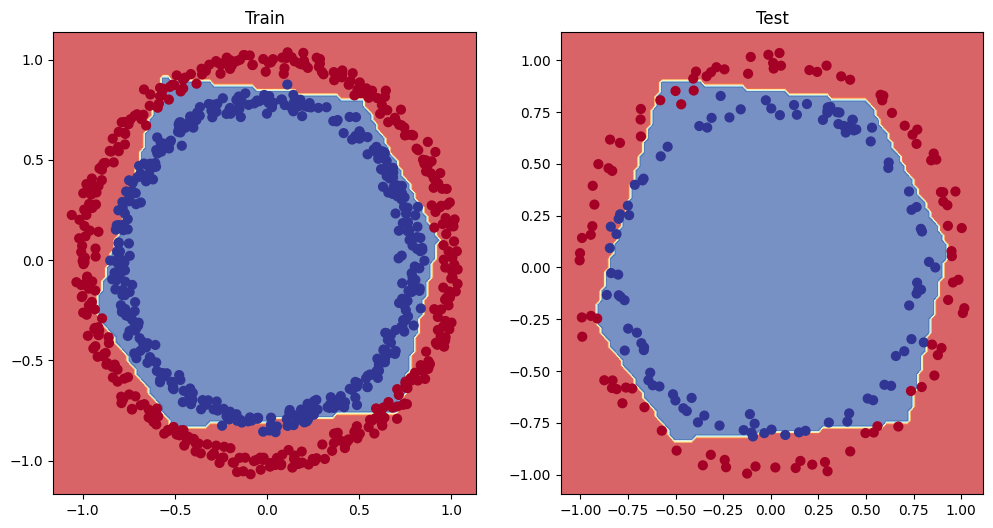

In [ ]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model1, x_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model1, x_test, y_test)

The decision boundary this time is much better than previous linear one, it can correctly segregate data

# Linear multi class classification

let's use sklearn's make_blobs to create a multi class problem dataset

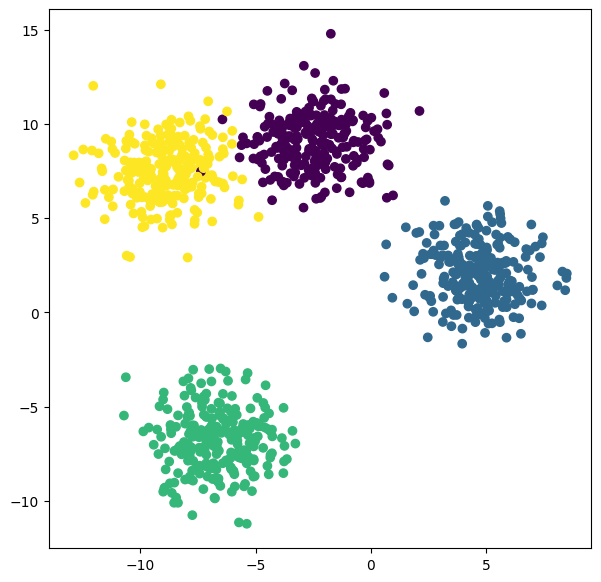

,X1,x2,label
0,-8.413396,6.935165,3
1,-5.766484,-6.431171,2
2,-6.042137,-6.766101,2
3,3.950837,0.698403,1
4,4.250492,-0.281545,1
5,-6.794107,-6.477221,2
6,5.210176,2.889048,1
7,-5.505136,-6.360377,2
8,-6.543756,-4.833899,2
9,6.449642,0.747766,1


In [ ]:
from sklearn.datasets import make_blobs;
from matplotlib import pyplot as plt;
import pandas as pd
import torch

samples = 1000
features = 2
classes = 4

x,y = make_blobs(n_samples=samples,n_features=2,centers=classes,cluster_std=1.5,random_state=42)

x = torch.from_numpy(x).type(torch.float)
y = torch.from_numpy(y).type(torch.long)

plt.figure(figsize=(7,7))

plt.scatter(x[:,0],x[:,1],c=y)
plt.show()

blobs = pd.DataFrame({
    "X1": x[:,0],
    "x2": x[:,1],
    "label": y
})
blobs.head(10)

## splitting the data

In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

print(len(x_train),len(x_test), len(y_train),len(y_test))

device = "cuda" if torch.cuda.is_available() else "cpu"

x_train = x_train.to(device)
x_test = x_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

800 200 800 200


## defining the model

In [ ]:
from torch import nn

class blob_model0(nn.Module):
  def __init__(self,input_units,output_units,hidden_units):
    super().__init__();
    self.network = nn.Sequential(
      nn.Linear(in_features=input_units,out_features=hidden_units),
      nn.Linear(in_features=hidden_units,out_features=hidden_units),
      nn.Linear(in_features=hidden_units,out_features=output_units)
    )

  def forward(self,x):
    return self.network(x)

model2 = blob_model0(
    input_units=features,
    output_units=classes,
    hidden_units=5
).to(device)

model2

blob_model0(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): Linear(in_features=5, out_features=5, bias=True)
    (2): Linear(in_features=5, out_features=4, bias=True)
  )
)

## training the model

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model2.parameters(),lr=0.1)


epochs = 100

for epoch in range(epochs):
  model2.train()

  y_logits = model2(x_train)
  y_preds = torch.softmax(y_logits,dim=1).argmax(dim=1)

  loss = loss_fn(y_logits,y_train)
  acc = accuracy_fn(y_true=y_train,y_pred=y_preds)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model2.eval()

  with torch.inference_mode():
      test_logits = model2(x_test)

      test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
      # 2. Calculate test loss and accuracy
      test_loss = loss_fn(test_logits, y_test)
      test_acc = accuracy_fn(y_true=y_test,
                             y_pred=test_pred)
  if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 1.32848, Acc: 24.38% | Test Loss: 1.55406, Test Acc: 53.50%
Epoch: 10 | Loss: 0.17941, Acc: 98.12% | Test Loss: 0.16558, Test Acc: 99.00%
Epoch: 20 | Loss: 0.09100, Acc: 99.12% | Test Loss: 0.08298, Test Acc: 99.50%
Epoch: 30 | Loss: 0.06453, Acc: 99.12% | Test Loss: 0.05711, Test Acc: 99.50%
Epoch: 40 | Loss: 0.05222, Acc: 99.12% | Test Loss: 0.04466, Test Acc: 99.50%
Epoch: 50 | Loss: 0.04527, Acc: 99.12% | Test Loss: 0.03747, Test Acc: 99.50%
Epoch: 60 | Loss: 0.04085, Acc: 99.12% | Test Loss: 0.03282, Test Acc: 99.50%
Epoch: 70 | Loss: 0.03783, Acc: 99.12% | Test Loss: 0.02958, Test Acc: 99.50%
Epoch: 80 | Loss: 0.03565, Acc: 99.12% | Test Loss: 0.02720, Test Acc: 99.50%
Epoch: 90 | Loss: 0.03400, Acc: 99.12% | Test Loss: 0.02537, Test Acc: 99.50%


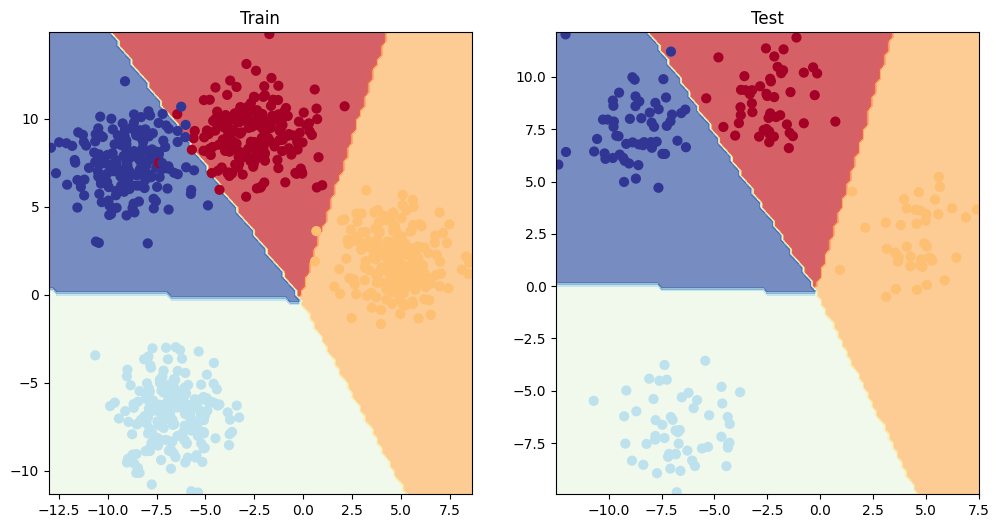

In [ ]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model2, x_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model2, x_test, y_test)

# Non-linear Multi class classification

the dataset for this problem is [taken from here](https://cs231n.github.io/neural-networks-case-study/)

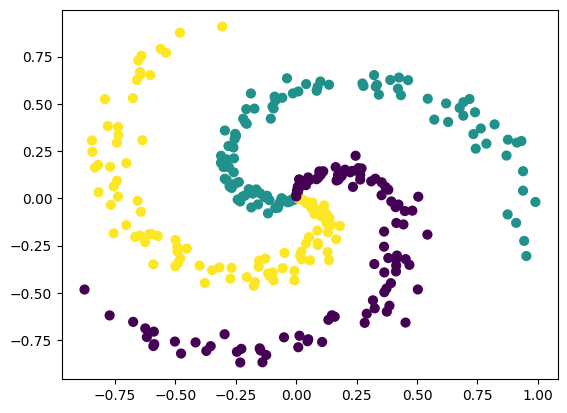

In [ ]:
# Code for creating a spiral dataset from CS231n
import numpy as np
from matplotlib import pyplot as plt
import torch

torch.manual_seed(42)
N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
x = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  x[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j

indices = np.random.permutation(N*K)

x = torch.from_numpy(x[indices]).type(torch.float)
y = torch.from_numpy(y[indices]).type(torch.float)
plt.scatter(x[:, 0], x[:, 1], c=y, s=40)
plt.show()

In [ ]:

from sklearn.model_selection import train_test_split
device = "cuda" if torch.cuda.is_available() else "cpu"

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

print(len(x_train),len(x_test),len(y_train),len(y_test))

x_train = x_train.to(device)
x_test = x_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

240 60 240 60


In [ ]:
from torch import nn

class spiralModel(nn.Module):
  def __init__(self,input_unit,output_unit,hidden_unit):
    super().__init__()
    self.network = nn.Sequential(
        nn.Linear(in_features=input_unit,out_features=hidden_unit),
        nn.ReLU(),
        nn.Linear(in_features=hidden_unit,out_features=hidden_unit),
        nn.ReLU(),
        nn.Linear(in_features=hidden_unit,out_features=output_unit)
    )

  def forward(self,x):
    return self.network(x)

model2 = spiralModel(
    input_unit=D,
    output_unit=K,
    hidden_unit=5
).to(device)
model2

spiralModel(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): ReLU()
    (2): Linear(in_features=5, out_features=5, bias=True)
    (3): ReLU()
    (4): Linear(in_features=5, out_features=3, bias=True)
  )
)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model2.parameters(),lr=0.3)

epochs = 3000

for epoch in range(epochs):
  model2.train()
  y_logits = model2(x_train)
  y_preds = torch.softmax(y_logits,dim=1).argmax(dim=1)

  acc = accuracy_fn(y_true=y_train,y_pred=y_preds)
  loss = loss_fn(y_logits,y_train.long())

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model2.eval()
  with torch.inference_mode():
      test_logits = model2(x_test)
      test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
      test_loss = loss_fn(test_logits, y_test.long())
      test_acc = accuracy_fn(y_true=y_test,
                             y_pred=test_pred)
  if epoch % 300 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 1.08825 Acc: 35.42% | Test Loss: 1.10427, Test Acc: 25.00%
Epoch: 300 | Loss: 0.55737 Acc: 71.67% | Test Loss: 0.65685, Test Acc: 71.67%
Epoch: 600 | Loss: 0.42323 Acc: 78.33% | Test Loss: 0.52523, Test Acc: 81.67%
Epoch: 900 | Loss: 0.32075 Acc: 87.92% | Test Loss: 0.47750, Test Acc: 88.33%
Epoch: 1200 | Loss: 0.24208 Acc: 90.83% | Test Loss: 0.36137, Test Acc: 86.67%
Epoch: 1500 | Loss: 0.14840 Acc: 93.75% | Test Loss: 0.18764, Test Acc: 93.33%
Epoch: 1800 | Loss: 0.12226 Acc: 93.75% | Test Loss: 0.13026, Test Acc: 96.67%
Epoch: 2100 | Loss: 0.10210 Acc: 94.58% | Test Loss: 0.10086, Test Acc: 96.67%
Epoch: 2400 | Loss: 0.09626 Acc: 95.42% | Test Loss: 0.08704, Test Acc: 96.67%
Epoch: 2700 | Loss: 0.08174 Acc: 95.83% | Test Loss: 0.07286, Test Acc: 96.67%


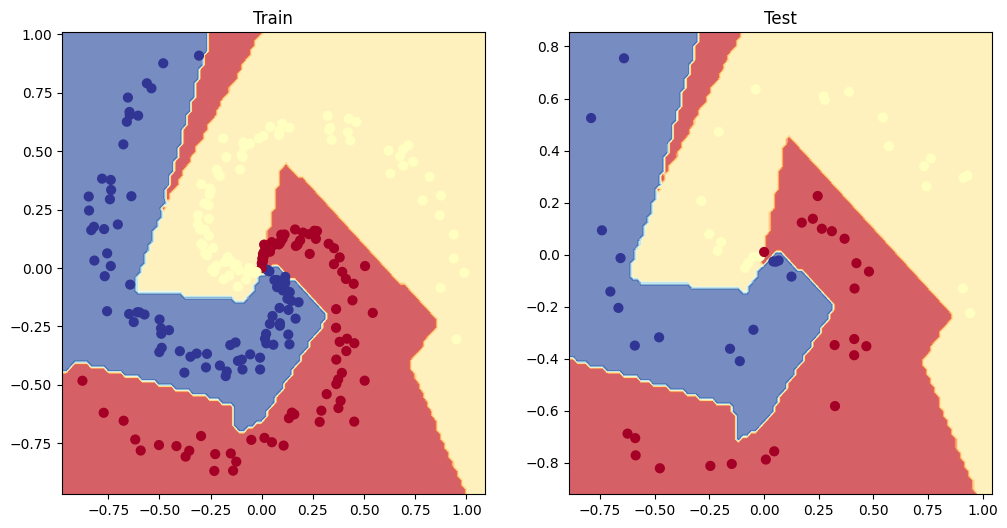

In [ ]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model2, x_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model2, x_test, y_test)